In [7]:
import time
import re
from pathlib import Path

import torch
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# pip install transformers
# pip install librosa
# pip install ipywidgets
# pip install PySoundFile
# conda install -c conda-forge libsndfile
# pip install sentencepiece
# pip install sacremoses

In [8]:
file_root = Path("/home/valvoja/projects/2026-Spring-Neural-Network-Project/assignment-3/hand-picked-dataset")

samples = [
    {
        "id": "file_1",
        "filename": "file_1.mp3",
        "description": "Easily understandable female voice",
        "reference": "Nykyiset rajoitustoimet ovat luonteeltaan pääasiassa hyvin yleisiä ja laajoja fyysisten kontaktien vähentämiseen tähtääviä rajoituksia",
    },
    {
        "id": "file_2",
        "filename": "file_2.mp3",
        "description": "Easily understandable male voice with slight background noise",
        "reference": "Suositusta on perusteltua jatkaa, jotta altistusta lähikontakteille ja tartuntariskille voidaan vähentää",
    },
    {
        "id": "file_3",
        "filename": "file_3.mp3",
        "description": "Faster speaking male voice",
        "reference": "Siikamäen rautatieasema on suomen rataverkolla pieksämäen kaupungissa eteläsavossa rataosalla pieksämäki-joensuu sijaitseva rautatieliikenne paikka",
    },
    {
        "id": "file_4",
        "filename": "file_4.mp3",
        "description": "Male voice with worse clarity and more noise",
        "reference": "Nämä ovat osoittautuneet oivalliseksi keinoksi rohkaista opiskelijoita ja opettajiakin harjaannuttamaan kielitaitoaan",
    },
    {
        "id": "file_5",
        "filename": "file_5.mp3",
        "description": "Non-native Finnish male speaker with accent",
        "reference": "En nimittäin ole tavannut ainuttakaan työnantajien edustajaa joka kannattaisi tätä tarkistusta",
    },
]

for sample in samples:
    sample["path"] = file_root / sample["filename"]

pd.DataFrame([
    {
        "id": sample["id"],
        "filename": sample["filename"],
        "description": sample["description"],
        "reference": sample["reference"],
    }
    for sample in samples
])


,id,filename,description
0,file_1,file_1.mp3,Easily understandable female voice
1,file_2,file_2.mp3,Easily understandable male voice with slight b...
2,file_3,file_3.mp3,Faster speaking male voice
3,file_4,file_4.mp3,Male voice with worse clarity and more noise
4,file_5,file_5.mp3,Non-native Finnish male speaker with accent


In [9]:
audio_info = []

for sample in samples:
    y, sr = librosa.load(str(sample["path"]), sr=16000)
    duration = librosa.get_duration(y=y, sr=sr)

    sample["audio"] = y
    sample["sr"] = sr
    sample["duration"] = duration

    print(f'{sample["id"]}: {sample["filename"]} ({duration:.2f} seconds)')
    display(Audio(y, rate=sr))

    audio_info.append({
        "id": sample["id"],
        "filename": sample["filename"],
        "sound_duration_seconds": round(duration, 2),
        "sample_rate": sr,
    })

audio_info_df = pd.DataFrame(audio_info)
audio_info_df

file_1: file_1.mp3 (9.33 seconds)


file_2: file_2.mp3 (10.49 seconds)


file_3: file_3.mp3 (9.91 seconds)


file_4: file_4.mp3 (10.03 seconds)


file_5: file_5.mp3 (13.50 seconds)


,id,filename,duration_seconds,sample_rate
0,file_1,file_1.mp3,9.33,16000
1,file_2,file_2.mp3,10.49,16000
2,file_3,file_3.mp3,9.91,16000
3,file_4,file_4.mp3,10.03,16000
4,file_5,file_5.mp3,13.50,16000


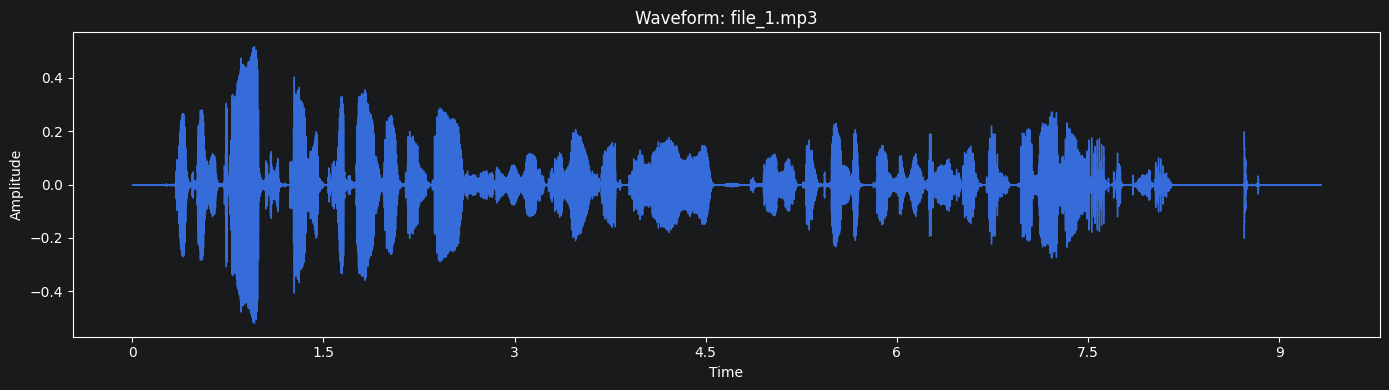

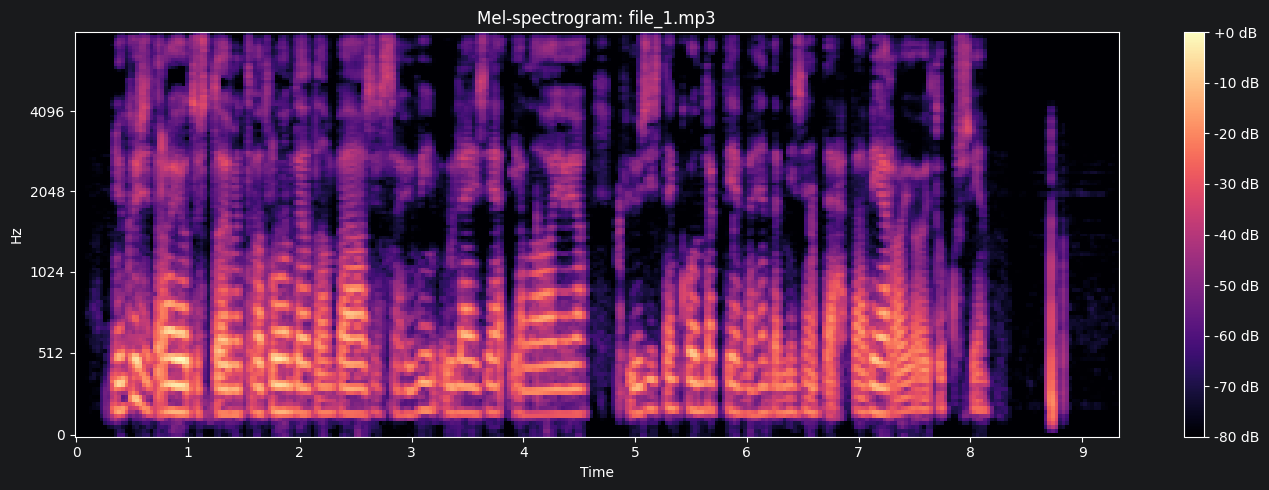

In [10]:
sample_index = 0
sample = samples[sample_index]
y = sample["audio"]
sr = sample["sr"]

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f'Waveform: {sample["filename"]}')
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(S_dB, y_axis="mel", x_axis="time", sr=sr)
plt.colorbar(format="%+2.0f dB")
plt.title(f'Mel-spectrogram: {sample["filename"]}')
plt.tight_layout()
plt.show()

In [11]:
def normalize_text(text):
    """Lowercase text and remove punctuation for a simple word-level comparison."""
    text = text.lower().strip()
    text = re.sub(r"[^a-zåäö0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text


def word_error_count(reference, prediction):
    """Return word-level edit distance between reference and prediction."""
    ref_words = normalize_text(reference).split()
    pred_words = normalize_text(prediction).split()

    dp = np.zeros((len(ref_words) + 1, len(pred_words) + 1), dtype=int)

    for i in range(len(ref_words) + 1):
        dp[i, 0] = i
    for j in range(len(pred_words) + 1):
        dp[0, j] = j

    for i in range(1, len(ref_words) + 1):
        for j in range(1, len(pred_words) + 1):
            substitution_cost = 0 if ref_words[i - 1] == pred_words[j - 1] else 1
            dp[i, j] = min(
                dp[i - 1, j] + 1,                         # deletion
                dp[i, j - 1] + 1,                         # insertion
                dp[i - 1, j - 1] + substitution_cost,     # substitution
            )

    return int(dp[len(ref_words), len(pred_words)]), len(ref_words)


def load_whisper_model(model_size):
    model_name = f"openai/whisper-{model_size}"
    print(f"Loading {model_name}...")

    processor = WhisperProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)
    model.eval()

    return processor, model


def transcribe_audio(audio, sample_rate, processor, model):
    input_features = processor(
        audio,
        sampling_rate=sample_rate,
        return_tensors="pt"
    ).input_features.to(device)

    start_time = time.perf_counter()

    with torch.no_grad():
        generated_ids = model.generate(
            input_features,
            language="fi",
            task="transcribe"
        )

    elapsed_seconds = time.perf_counter() - start_time

    transcription = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0].strip()

    return transcription, elapsed_seconds

In [12]:
model_sizes = ["tiny", "medium"]

device = "cuda" if torch.cuda.is_available() else "cpu"
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"

print(f"Using device: {device}")

Using device: cuda


In [13]:
missing_transcripts = [
    sample["id"]
    for sample in samples
    if sample["reference"].strip() == "WRITE TRANSCRIPT HERE"
]

if missing_transcripts:
    raise ValueError(
        "Fill in the manual reference transcripts before running the comparison. "
        f"Missing: {missing_transcripts}"
    )

In [17]:
results = []

for model_size in model_sizes:
    processor, model = load_whisper_model(model_size)

    for sample in samples:
        prediction, elapsed_seconds = transcribe_audio(
            sample["audio"],
            sample["sr"],
            processor,
            model,
        )

        errors, reference_word_count = word_error_count(sample["reference"], prediction)
        wer_percent = 100 * errors / reference_word_count if reference_word_count > 0 else np.nan

        results.append({
            "model": model_size,
            "id": sample["id"],
            "filename": sample["filename"],
            "sound_duration_seconds": round(sample["duration"], 2),
            "transcript_time_seconds": round(elapsed_seconds, 2),
            "reference_word_count": reference_word_count,
            "word_errors": errors,
            "WER_percent": round(wer_percent, 2),
            "reference": sample["reference"],
            "prediction": prediction,
        })

        print(f'[{model_size}] {sample["id"]}: {errors} word errors, {elapsed_seconds:.2f} seconds')
        print("Prediction:", prediction)
        print("Reference:", sample["reference"])
        print()

    del model
    del processor

    if device == "cuda":
        torch.cuda.empty_cache()

results_df = pd.DataFrame(results)
results_df

Loading openai/whisper-tiny...


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

[tiny] file_1: 12 word errors, 0.34 seconds
Prediction: Nyt kysit rajotustoimet ovat luonteltaan pääsessä hyvin yleisijä ja laajia, kyysisten kontakteivä hentä misentää vieraoituksia.
Reference: Nykyiset rajoitustoimet ovat luonteeltaan pääasiassa hyvin yleisiä ja laajoja fyysisten kontaktien vähentämiseen tähtääviä rajoituksia

[tiny] file_2: 4 word errors, 0.26 seconds
Prediction: Suositusta on perusteltua jätkää, jotta autistusta leikontakteille ja tartuntariskille voidaan määhentää.
Reference: Suositusta on perusteltua jatkaa, jotta altistusta lähikontakteille ja tartuntariskille voidaan vähentää

[tiny] file_3: 18 word errors, 0.54 seconds
Prediction: Siikä meidän rautotia asemaa on suomen rata-verkolla PX-main kaupungissa, etellä samosarata osalla PX-makin join suuu sijatsivaa rautotia liikenne paikka.
Reference: Siikamäen rautatieasema on suomen rataverkolla pieksämäen kaupungissa eteläsavossa rataosalla pieksämäki-joensuu sijaitseva rautatieliikenne paikka

[tiny] file_4: 12 wo

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

[medium] file_1: 5 word errors, 1.55 seconds
Prediction: Nykyiset rajoitustoimittavat luonteelta on pääasiassa hyvin yleisiä ja laajoja fyysisten kontaktien vähentämisen tähtävien rajoituksia.
Reference: Nykyiset rajoitustoimet ovat luonteeltaan pääasiassa hyvin yleisiä ja laajoja fyysisten kontaktien vähentämiseen tähtääviä rajoituksia

[medium] file_2: 1 word errors, 1.20 seconds
Prediction: Suositusta on perusteltua jatkaa, jotta altistusta lehikontakteille ja tartuntariskille voidaan vähentää.
Reference: Suositusta on perusteltua jatkaa, jotta altistusta lähikontakteille ja tartuntariskille voidaan vähentää

[medium] file_3: 6 word errors, 1.93 seconds
Prediction: Siikamäen rautatieasema on Suomen rataverkolla Pieksemäen kaupungissa etelä-Savossa rataosalla Pieksemäki-Joensuu sijaitseva rautatieliikennepaikka.
Reference: Siikamäen rautatieasema on suomen rataverkolla pieksämäen kaupungissa eteläsavossa rataosalla pieksämäki-joensuu sijaitseva rautatieliikenne paikka

[medium] file_

,model,id,filename,duration_seconds,time_seconds,reference_word_count,word_errors,WER_percent,reference,prediction
0,tiny,file_1,file_1.mp3,9.33,0.34,14,12,85.71,Nykyiset rajoitustoimet ovat luonteeltaan pääa...,Nyt kysit rajotustoimet ovat luonteltaan pääse...
1,tiny,file_2,file_2.mp3,10.49,0.26,11,4,36.36,"Suositusta on perusteltua jatkaa, jotta altist...","Suositusta on perusteltua jätkää, jotta autist..."
2,tiny,file_3,file_3.mp3,9.91,0.54,14,18,128.57,Siikamäen rautatieasema on suomen rataverkolla...,Siikä meidän rautotia asemaa on suomen rata-ve...
3,tiny,file_4,file_4.mp3,10.03,0.32,11,12,109.09,Nämä ovat osoittautuneet oivalliseksi keinoksi...,Nämä ovat tos oittaa tunnet oivalliseksi keinn...
4,tiny,file_5,file_5.mp3,13.50,0.25,11,7,63.64,En nimittäin ole tavannut ainuttakaan työnanta...,En nimittäin ole tavannut ainnuttakaan työnnan...
5,medium,file_1,file_1.mp3,9.33,1.55,14,5,35.71,Nykyiset rajoitustoimet ovat luonteeltaan pääa...,Nykyiset rajoitustoimittavat luonteelta on pää...
6,medium,file_2,file_2.mp3,10.49,1.20,11,1,9.09,"Suositusta on perusteltua jatkaa, jotta altist...","Suositusta on perusteltua jatkaa, jotta altist..."
7,medium,file_3,file_3.mp3,9.91,1.93,14,6,42.86,Siikamäen rautatieasema on suomen rataverkolla...,Siikamäen rautatieasema on Suomen rataverkolla...
8,medium,file_4,file_4.mp3,10.03,1.36,11,2,18.18,Nämä ovat osoittautuneet oivalliseksi keinoksi...,Nämä ovat osoittautuneet toivolliseksi keinoik...
9,medium,file_5,file_5.mp3,13.50,1.18,11,2,18.18,En nimittäin ole tavannut ainuttakaan työnanta...,En nimittäin ole tavannut ainuttakaan työnanta...


In [15]:
# Per-model averages
summary_df = (
    results_df
    .groupby("model", as_index=False)
    .agg(
        total_word_errors=("word_errors", "sum"),
        average_WER_percent=("WER_percent", "mean"),
        total_time_seconds=("time_seconds", "sum"),
        average_time_seconds=("time_seconds", "mean"),
    )
)

summary_df

,model,total_word_errors,average_WER_percent,total_time_seconds,average_time_seconds
0,medium,16,24.804,7.39,1.478
1,tiny,53,84.674,2.63,0.526


In [16]:
# Side-by-side comparison for each file
comparison_df = results_df.pivot_table(
    index=["id", "filename"],
    columns="model",
    values=["word_errors", "WER_percent", "time_seconds"],
    aggfunc="first"
)

comparison_df

WER_percent         time_seconds       word_errors     
model                  medium    tiny       medium  tiny      medium tiny
id     filename                                                          
file_1 file_1.mp3       35.71   85.71         1.54  1.27           5   12
file_2 file_2.mp3        9.09   36.36         1.32  0.28           1    4
file_3 file_3.mp3       42.86  128.57         1.97  0.47           6   18
file_4 file_4.mp3       18.18  109.09         1.43  0.36           2   12
file_5 file_5.mp3       18.18   63.64         1.13  0.25           2    7